In [96]:
import numpy as np
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister, transpile
from qiskit.visualization import plot_histogram, plot_state_city
from itertools import product
from tqdm import tqdm

# Definition of th sign flip

$$\operatorname{SF}_{N,j} = O_j (C^NZ) O_j$$

$$O_j = \otimes_{l=0}^{N-1} (\operatorname{NOT}_l)^{1-j_l}$$

Choose $N$ and $j$. $j$ represents the elements of the computational basis.

In [97]:
def num2bin(num, n):
    return np.array([int(i) for i in np.binary_repr(num, n)])

def O(q, j):
    O_circ = QuantumCircuit(q, name=f"O_{''.join([str(i) for i in j])}")

    for (i, v) in enumerate(j):
        if v == 0:
            O_circ.x(q[i])
    return  O_circ

def sf(q, j):
    N = q.size
    SF = QuantumCircuit(q, name=f"SF_{q.size}_{''.join([str(i) for i in j])}")
    SF.append(O(q, j), q)
    SF.barrier(q)
    SF.mcrz(np.pi, q[:N-1], q[N-1])
    SF.barrier(q)
    SF.append(O(q, j), q)    
    return SF

In [98]:
def U_i(q, input_vector):
    u_i = QuantumCircuit(q, name=f"U^i_{''.join([str(i) for i in input_vector])}")
    N = q.size
    u_i.h(q)
    for (i, v) in enumerate(input_vector):
        if v:
            bin_num = num2bin(i, N)
            u_i.append(sf(q, bin_num), q)
    return u_i

In [99]:
def U_w(q, weight_vector):
    u_w = QuantumCircuit(q, name=f"U^w_{''.join([str(i) for i in weight_vector])}")
    N = q.size
    for (i, v) in enumerate(weight_vector):
        if v:
            bin_num = num2bin(i, N)
            u_w.append(sf(q, bin_num), q)
    u_w.h(q)
    u_w.x(q)
    return u_w

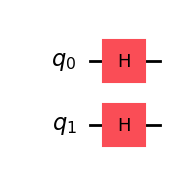

In [100]:
N = 2
q = QuantumRegister(N, 'q')
input_vector = [0, 0, 0, 0]
circ = QuantumCircuit(q)
circ.append(U_i(q, input_vector), q)
circ.decompose(reps=1).draw(output='mpl')

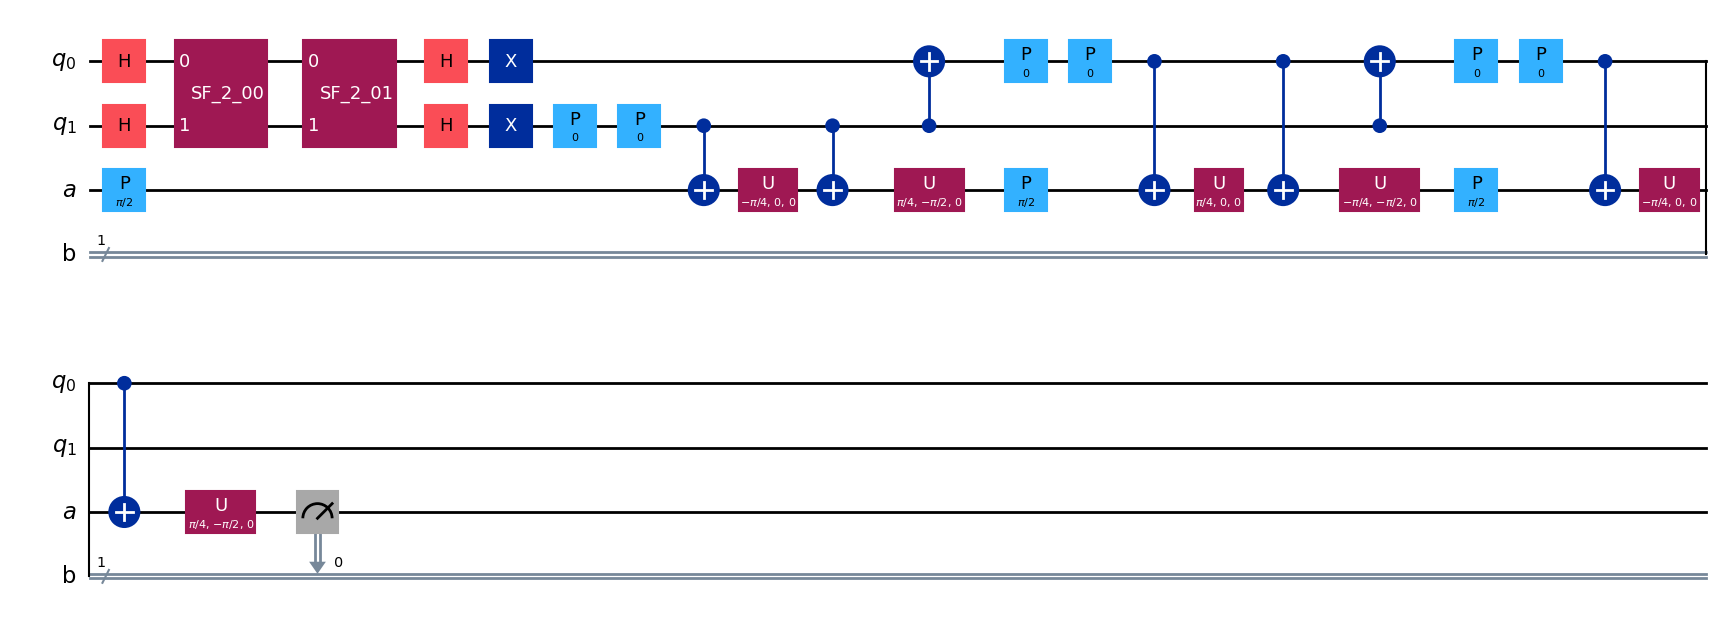

In [101]:
N = 2
q = QuantumRegister(N, 'q')
a = QuantumRegister(1, 'a')
b = ClassicalRegister(1, 'b')
circ = QuantumCircuit(q, a, b)
circ.append(U_i(q, num2bin(0, N)[::-1]), q)
circ.append(U_w(q, num2bin(3, N)), q)
circ.mcrx(np.pi, q, a[0])
circ.measure(a, b)
circ.decompose(reps=1).draw(output='mpl')


Total counts are: {'1': 1024}


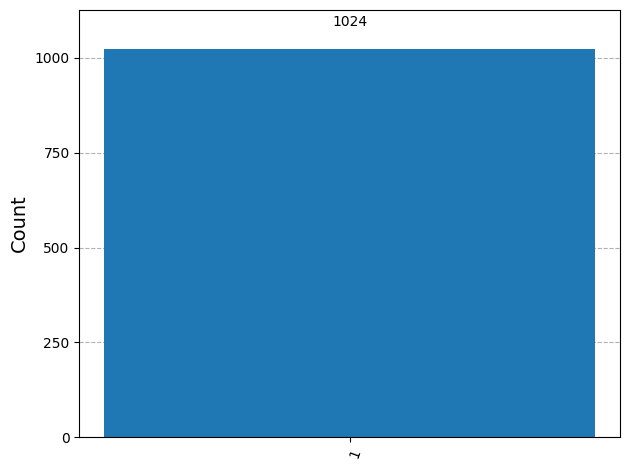

In [102]:
simulator = AerSimulator()
job = simulator.run(transpile(circ, simulator), shots=1024)
result = job.result()
counts = result.get_counts(circ)
print("\nTotal counts are:",counts)
plot_histogram(counts)

# Input vs weights matrix

Below we compare all the input vectors against all the weight vectors, for a specified $N$. We're computing a square matrix with a side of $2^{2^N}$ elements.

Start with $N=2$ to see results within your lifetime.

The results are saved in **outcomes**, and can be viewed in an image in the cell below.

In [116]:
N = 2
shots = 1024
outcomes = np.zeros((2**(2**N),2**(2**N)))
for (i, w) in tqdm(product(range(2**(2**N)), repeat=2)):
    q = QuantumRegister(N, 'q')
    a = QuantumRegister(1, 'a')
    b = ClassicalRegister(1, 'b')
    circ = QuantumCircuit(q, a, b)
    circ.append(U_i(q, num2bin(i, 2*N)), q)
    circ.append(U_w(q, num2bin(w, 2*N)), q)
    circ.mcrx(np.pi, q, a[0])
    circ.measure(a, b)

    simulator = AerSimulator()
    job = simulator.run(transpile(circ, simulator), shots=shots)
    result = job.result()
    counts = result.get_counts(circ)
    outcomes[i][w] = counts.get('1', 0) / shots
    print(i, w, counts)

2it [00:00, 12.45it/s]

0 0 {'1': 1024}
0 1 {'1': 263, '0': 761}
0 2 {'1': 252, '0': 772}


6it [00:00, 13.38it/s]

0 3 {'1': 1024}
0 4 {'1': 231, '0': 793}
0 5 {'0': 1024}


8it [00:00, 13.63it/s]

...

15 9 {'0': 1024}
15 10 {'0': 1024}
15 11 {'1': 258, '0': 766}


254it [00:18, 13.88it/s]

15 12 {'1': 1024}
15 13 {'1': 271, '0': 753}
15 14 {'1': 269, '0': 755}


256it [00:18, 13.94it/s]

15 15 {'1': 1024}


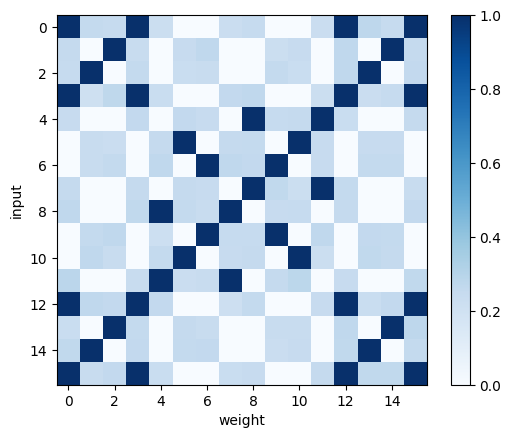

In [117]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.set_xlabel("weight")
ax.set_ylabel("input")

out_plot = ax.imshow(outcomes, cmap='Blues', interpolation='none')
fig.colorbar(out_plot, ax=ax)